# ResNet-18 PCA variance and visual extrema

This notebook analyzes the **raw, non-inverted** frozen ResNet-18 embeddings. No global spin symmetry is imposed before the network.

It answers four questions:

1. How is explained variance distributed across principal components?
2. How many PCs are needed to capture 90% of the embedding variance?
3. What do the actual configurations at the negative and positive extrema of PCs 1–5 look like?
4. Do the leading PCs encode uniform, location-dependent, or Fourier-mode magnetization?


In [1]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

L = 16
N_SITES = L ** 2
N_RUNS = 1_000
N_TEMPERATURES = 31
BINS_PER_TEMPERATURE = 10
N_CONFIGURATIONS = N_RUNS * N_TEMPERATURES * BINS_PER_TEMPERATURE

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1]]
REPO_ROOT = next(root for root in candidate_roots if (root / "data" / "raw").exists())
DATA_ROOT = REPO_ROOT / "data" / "raw"
OUTPUT_ROOT = REPO_ROOT / "data" / "processed"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

EMBEDDING_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_embeddings.npy"
TEMPERATURE_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_temperatures.npy"
MAGNETIZATION_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_signed_magnetization.npy"

assert EMBEDDING_PATH.exists(), "Run ising16_magnetization.ipynb first to create raw ResNet embeddings."
embeddings = np.load(EMBEDDING_PATH, mmap_mode="r")
embedding_temperatures = np.load(TEMPERATURE_PATH)
assert embeddings.shape == (N_CONFIGURATIONS, 512)

run_dirs = sorted(
    DATA_ROOT.glob("ising16_tc_[0-9]*"),
    key=lambda path: int(path.name.rsplit("_", 1)[1]),
)
assert len(run_dirs) == N_RUNS

temperature_grid = embedding_temperatures.reshape(
    N_RUNS, N_TEMPERATURES, BINS_PER_TEMPERATURE
)
temperatures = temperature_grid[0, :, 0]
assert np.all(temperature_grid == temperatures[None, :, None])

print(f"Embeddings: {embeddings.shape}")
print(f"Temperatures: {temperatures[0]:g} to {temperatures[-1]:g}")

Embeddings: (310000, 512)
Temperatures: 1.5 to 3


## Magnetization calculated directly from spins

Signed magnetization is recomputed as $m=\sum_i s_i/L^2$ and cached for later notebooks.

In [2]:
if MAGNETIZATION_PATH.exists():
    signed_magnetization = np.load(MAGNETIZATION_PATH)
else:
    signed_magnetization = np.empty(N_CONFIGURATIONS, dtype=np.float32)
    offset = 0
    for run_index, run_dir in enumerate(run_dirs):
        suffix = run_dir.name
        spins = np.loadtxt(
            run_dir / f"spinConfigs_{suffix}.txt", dtype=np.int8
        )
        count = len(spins)
        signed_magnetization[offset:offset + count] = (
            spins.sum(axis=1, dtype=np.int32) / N_SITES
        )
        offset += count
        if (run_index + 1) % 200 == 0:
            print(f"Read {run_index + 1:,}/{N_RUNS:,} runs")
    assert offset == N_CONFIGURATIONS
    np.save(MAGNETIZATION_PATH, signed_magnetization)

abs_magnetization = np.abs(signed_magnetization)
print(f"Magnetization cache: {signed_magnetization.shape}")

Magnetization cache: (310000,)


## Exact covariance eigendecomposition

The 512×512 covariance is accumulated in GPU-friendly batches and diagonalized exactly. This avoids guessing a component cutoff with a truncated PCA solver.

In [3]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
COVARIANCE_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_covariance.npz"

if COVARIANCE_PATH.exists():
    covariance_cache = np.load(COVARIANCE_PATH)
    feature_mean = covariance_cache["feature_mean"]
    eigenvalues = covariance_cache["eigenvalues"]
    components = covariance_cache["components"]
else:
    feature_sum = torch.zeros(512, dtype=torch.float64, device=DEVICE)
    second_moment = torch.zeros((512, 512), dtype=torch.float64, device=DEVICE)
    batch_size = 8_192

    for start in range(0, N_CONFIGURATIONS, batch_size):
        stop = min(start + batch_size, N_CONFIGURATIONS)
        batch = torch.from_numpy(np.asarray(embeddings[start:stop])).to(
            DEVICE, dtype=torch.float64
        )
        feature_sum += batch.sum(dim=0)
        second_moment += batch.T @ batch

    feature_mean_tensor = feature_sum / N_CONFIGURATIONS
    covariance = (
        second_moment - N_CONFIGURATIONS * torch.outer(feature_mean_tensor, feature_mean_tensor)
    ) / (N_CONFIGURATIONS - 1)
    eigenvalues_tensor, eigenvectors_tensor = torch.linalg.eigh(covariance)
    order = torch.argsort(eigenvalues_tensor, descending=True)

    eigenvalues = eigenvalues_tensor[order].cpu().numpy()
    components = eigenvectors_tensor[:, order].T.cpu().numpy()
    feature_mean = feature_mean_tensor.cpu().numpy()
    np.savez(
        COVARIANCE_PATH,
        feature_mean=feature_mean,
        eigenvalues=eigenvalues,
        components=components,
    )

explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)
n_components_90 = int(np.searchsorted(cumulative_variance, 0.90) + 1)

print(f"Device: {DEVICE}")
print(f"PCs required for 90% variance: {n_components_90}")
print(f"Variance retained: {cumulative_variance[n_components_90 - 1]:.3%}")

Device: cuda
PCs required for 90% variance: 22
Variance retained: 90.055%


## Explained-variance bar chart

Bars show the individual explained-variance ratio for every PC retained by the 90% cutoff. The cumulative curve is included on a second axis to make the cutoff explicit.

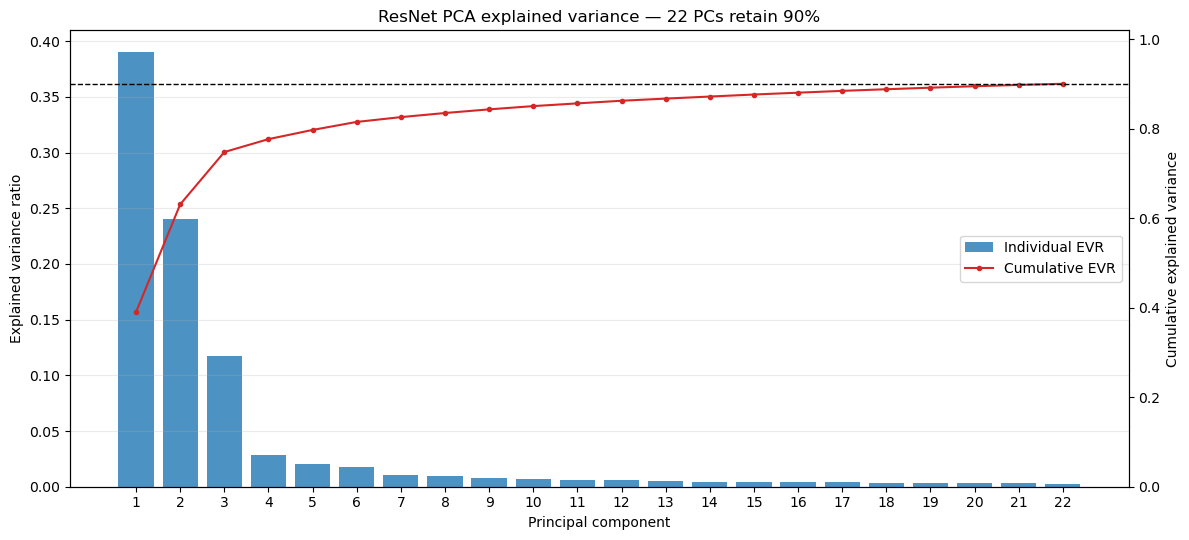

In [4]:
retained_pc_numbers = np.arange(1, n_components_90 + 1)

fig, ax = plt.subplots(figsize=(12, 5.5))
bars = ax.bar(
    retained_pc_numbers,
    explained_variance_ratio[:n_components_90],
    color="tab:blue",
    alpha=0.8,
    label="Individual EVR",
)
ax.set(
    xlabel="Principal component",
    ylabel="Explained variance ratio",
    title=f"ResNet PCA explained variance — {n_components_90} PCs retain 90%",
    xticks=retained_pc_numbers,
)
ax.grid(axis="y", alpha=0.25)

cumulative_axis = ax.twinx()
cumulative_axis.plot(
    retained_pc_numbers,
    cumulative_variance[:n_components_90],
    color="tab:red",
    marker="o",
    markersize=3,
    label="Cumulative EVR",
)
cumulative_axis.axhline(0.90, color="black", linestyle="--", linewidth=1)
cumulative_axis.set_ylabel("Cumulative explained variance")
cumulative_axis.set_ylim(0, 1.02)

handles_1, labels_1 = ax.get_legend_handles_labels()
handles_2, labels_2 = cumulative_axis.get_legend_handles_labels()
ax.legend(handles_1 + handles_2, labels_1 + labels_2, loc="center right")
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ising16_resnet18_raw_pca_variance_bars.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)

In [5]:
SCORES_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_pca90_scores.npy"
PCA_METADATA_PATH = OUTPUT_ROOT / "ising16_resnet18_raw_pca90_metadata.json"

if SCORES_PATH.exists():
    pca90_scores = np.load(SCORES_PATH, mmap_mode="r")
else:
    pca90_scores = np.lib.format.open_memmap(
        SCORES_PATH,
        mode="w+",
        dtype=np.float32,
        shape=(N_CONFIGURATIONS, n_components_90),
    )
    for start in range(0, N_CONFIGURATIONS, 8_192):
        stop = min(start + 8_192, N_CONFIGURATIONS)
        centered = np.asarray(embeddings[start:stop]) - feature_mean
        pca90_scores[start:stop] = centered @ components[:n_components_90].T
    pca90_scores.flush()

with open(PCA_METADATA_PATH, "w") as handle:
    json.dump(
        {
            "n_components_90": n_components_90,
            "variance_retained": float(cumulative_variance[n_components_90 - 1]),
            "n_configurations": N_CONFIGURATIONS,
            "embedding_dimension": 512,
            "spin_inversion_used": False,
        },
        handle,
        indent=2,
    )

## Visual extrema of PCs 1–5

For each component, the left panel is the **actual 16×16 configuration with the minimum score** and the right panel is the actual configuration with the maximum score. Nothing is averaged or reconstructed. Titles report temperature, signed magnetization, and PC score so the visual direction of each component can be interpreted directly.

The sign of a PCA component is mathematically arbitrary; “minimum” and “maximum” describe the fitted orientation, not an intrinsic physical sign.

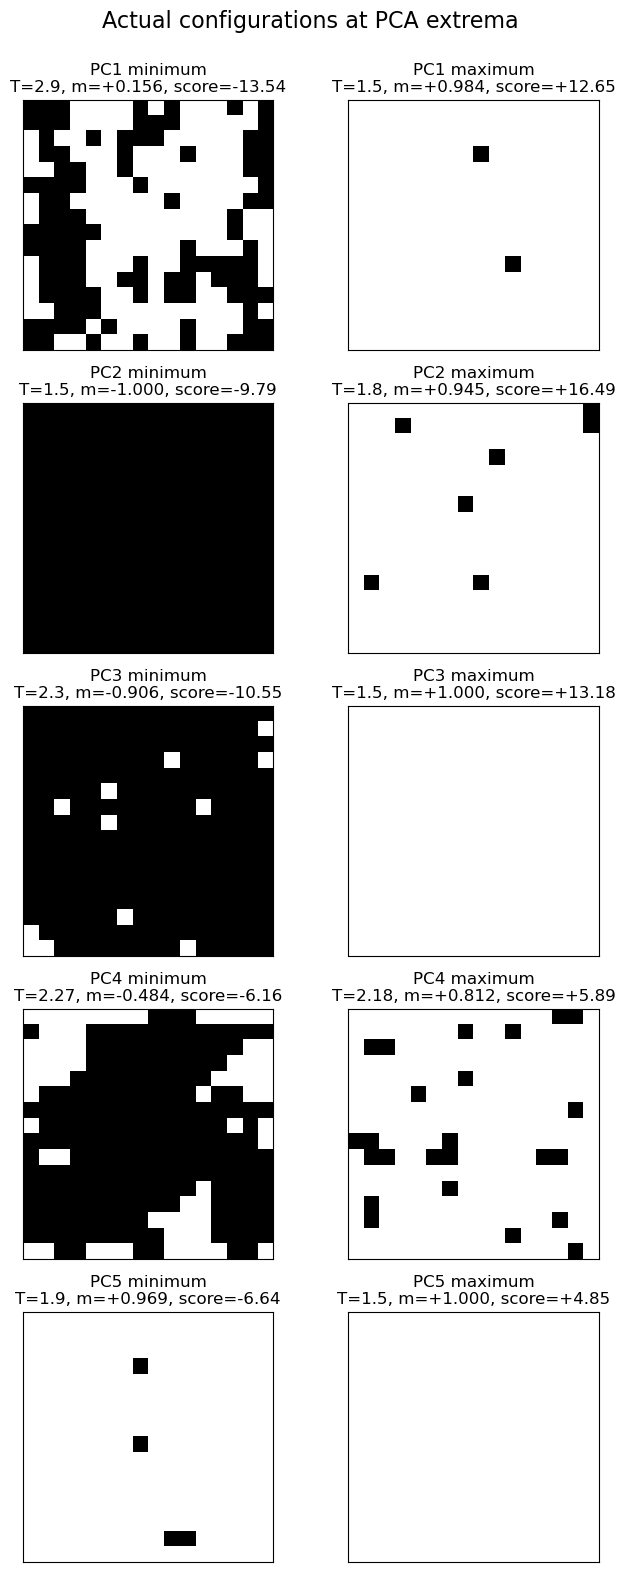

,principal_component,extremum,global_index,temperature,signed_magnetization,pc_score
0,1,minimum,30984,2.90,0.156250,-13.541574
1,1,maximum,61079,1.50,0.984375,12.650054
2,2,minimum,5,1.50,-1.000000,-9.793309
3,2,maximum,263842,1.80,0.945312,16.486181
4,3,minimum,257483,2.30,-0.906250,-10.546813
5,3,maximum,6,1.50,1.000000,13.184939
6,4,minimum,179336,2.27,-0.484375,-6.159313
7,4,maximum,109834,2.18,0.812500,5.889070
8,5,minimum,287728,1.90,0.968750,-6.643262
9,5,maximum,6,1.50,1.000000,4.846273


In [6]:
def load_spin_configuration(global_index):
    configurations_per_run = N_TEMPERATURES * BINS_PER_TEMPERATURE
    run_index, row_index = divmod(int(global_index), configurations_per_run)
    run_dir = run_dirs[run_index]
    suffix = run_dir.name
    configuration = np.loadtxt(
        run_dir / f"spinConfigs_{suffix}.txt",
        dtype=np.int8,
        skiprows=row_index,
        max_rows=1,
    )
    return configuration.reshape(L, L)

extrema_rows = []
fig, axes = plt.subplots(5, 2, figsize=(7, 16))

for pc_index in range(5):
    scores = np.asarray(pca90_scores[:, pc_index])
    minimum_index = int(np.argmin(scores))
    maximum_index = int(np.argmax(scores))

    for column, (label, sample_index) in enumerate((
        ("minimum", minimum_index),
        ("maximum", maximum_index),
    )):
        configuration = load_spin_configuration(sample_index)
        temperature = float(embedding_temperatures[sample_index])
        magnetization = float(signed_magnetization[sample_index])
        score = float(scores[sample_index])

        axes[pc_index, column].imshow(
            configuration,
            cmap="gray",
            vmin=-1,
            vmax=1,
            interpolation="nearest",
        )
        axes[pc_index, column].set_title(
            f"PC{pc_index + 1} {label}\n"
            f"T={temperature:g}, m={magnetization:+.3f}, score={score:+.2f}"
        )
        axes[pc_index, column].set_xticks([])
        axes[pc_index, column].set_yticks([])

        extrema_rows.append({
            "principal_component": pc_index + 1,
            "extremum": label,
            "global_index": sample_index,
            "temperature": temperature,
            "signed_magnetization": magnetization,
            "pc_score": score,
        })

fig.suptitle("Actual configurations at PCA extrema", fontsize=16)
fig.tight_layout(rect=(0, 0, 1, 0.98))
fig.savefig(OUTPUT_ROOT / "ising16_resnet18_raw_pc1-5_extrema.png", dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)

extrema_table = pd.DataFrame(extrema_rows)
extrema_table.to_csv(OUTPUT_ROOT / "ising16_resnet18_raw_pc1-5_extrema.csv", index=False)
extrema_table

## Spatial interpretation of PCs 1–5

An individual extremum can be atypical, so this section compares the **lowest and highest 2% of scores** for each PC. The tail-averaged spin maps show where magnetization changes consistently across many configurations. Their difference is a direct empirical real-space representation of each PC direction; it is not a reconstruction through ResNet.

Because the simulation has periodic boundaries and no preferred location, a stable center, edge, left, or right pattern would not be a new Ising order parameter. It would instead indicate finite-sample noise or position sensitivity introduced by resizing and the pretrained image network.

In [7]:
SPINS_PATH = OUTPUT_ROOT / "ising16_raw_spins.npy"

if SPINS_PATH.exists():
    all_spins = np.load(SPINS_PATH, mmap_mode="r")
else:
    spin_cache = np.lib.format.open_memmap(
        SPINS_PATH,
        mode="w+",
        dtype=np.int8,
        shape=(N_CONFIGURATIONS, L, L),
    )
    offset = 0
    for run_index, run_dir in enumerate(run_dirs):
        suffix = run_dir.name
        run_spins = np.loadtxt(
            run_dir / f"spinConfigs_{suffix}.txt", dtype=np.int8
        ).reshape(-1, L, L)
        spin_cache[offset:offset + len(run_spins)] = run_spins
        offset += len(run_spins)
        if (run_index + 1) % 200 == 0:
            print(f"Cached {run_index + 1:,}/{N_RUNS:,} runs")
    spin_cache.flush()
    del spin_cache
    all_spins = np.load(SPINS_PATH, mmap_mode="r")

assert all_spins.shape == (N_CONFIGURATIONS, L, L)
print(f"Spin cache: {all_spins.shape}")

Spin cache: (310000, 16, 16)


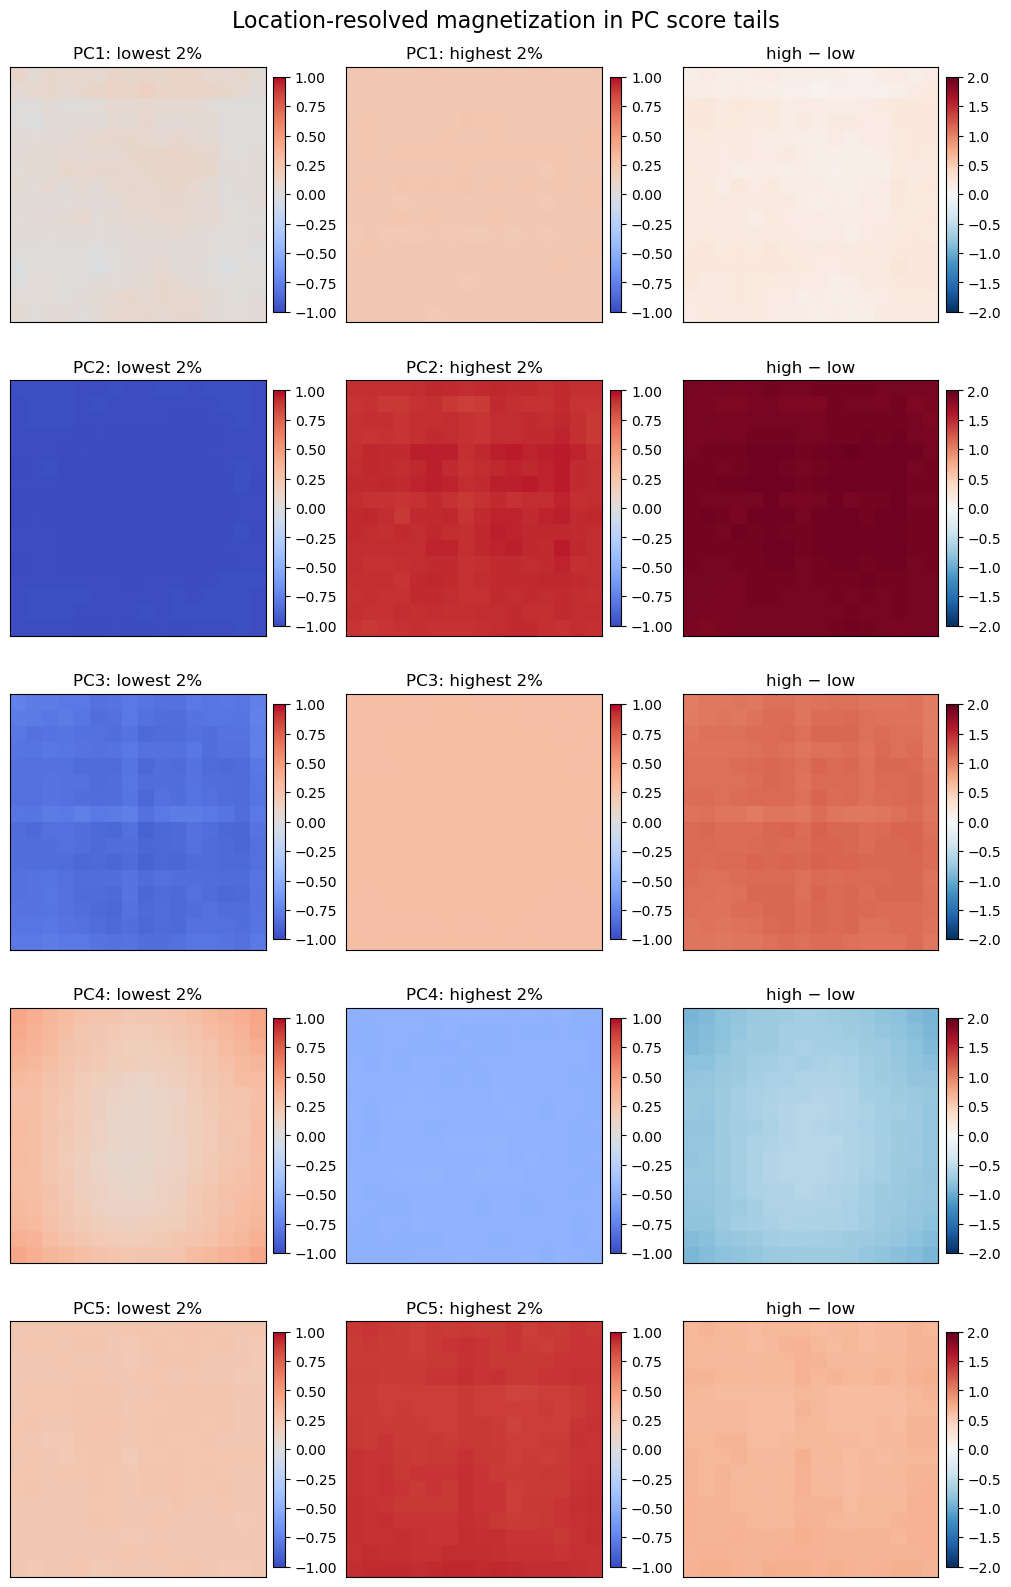

,principal_component,tail_fraction,low_mean_m,high_mean_m,spatial_contrast_std,spatial_contrast_range
0,1,0.02,0.049351,0.220508,0.031123,0.160000
1,2,0.02,-0.991271,0.919415,0.019057,0.107742
2,3,0.02,-0.827719,0.284724,0.030905,0.158064
3,4,0.02,0.230159,-0.479109,0.084461,0.362903
4,5,0.02,0.225954,0.890709,0.022284,0.108387


In [8]:
TAIL_FRACTION = 0.02
tail_count = int(TAIL_FRACTION * N_CONFIGURATIONS)
tail_map_rows = []

fig, axes = plt.subplots(5, 3, figsize=(10, 16), constrained_layout=True)
for pc_index in range(5):
    scores = np.asarray(pca90_scores[:, pc_index])
    order = np.argsort(scores)
    low_indices = order[:tail_count]
    high_indices = order[-tail_count:]

    low_map = np.asarray(all_spins[low_indices], dtype=np.float32).mean(axis=0)
    high_map = np.asarray(all_spins[high_indices], dtype=np.float32).mean(axis=0)
    contrast_map = high_map - low_map

    panels = (
        (low_map, f"PC{pc_index + 1}: lowest 2%", "coolwarm", -1, 1),
        (high_map, f"PC{pc_index + 1}: highest 2%", "coolwarm", -1, 1),
        (contrast_map, "high − low", "RdBu_r", -2, 2),
    )
    for column, (image_data, title, cmap, vmin, vmax) in enumerate(panels):
        image = axes[pc_index, column].imshow(
            image_data, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest"
        )
        axes[pc_index, column].set_title(title)
        axes[pc_index, column].set_xticks([])
        axes[pc_index, column].set_yticks([])
        fig.colorbar(image, ax=axes[pc_index, column], fraction=0.046, pad=0.03)

    tail_map_rows.append({
        "principal_component": pc_index + 1,
        "tail_fraction": TAIL_FRACTION,
        "low_mean_m": float(low_map.mean()),
        "high_mean_m": float(high_map.mean()),
        "spatial_contrast_std": float(contrast_map.std()),
        "spatial_contrast_range": float(np.ptp(contrast_map)),
    })

fig.suptitle("Location-resolved magnetization in PC score tails", fontsize=16)
fig.savefig(
    OUTPUT_ROOT / "ising16_resnet18_raw_pc1-5_spatial_tail_maps.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

tail_map_summary = pd.DataFrame(tail_map_rows)
tail_map_summary.to_csv(
    OUTPUT_ROOT / "ising16_resnet18_raw_pc1-5_spatial_tail_summary.csv", index=False
)
tail_map_summary

### Mean-subtracted local magnetization

To separate **where** the spins are magnetized from the total signed magnetization, subtract each configuration's own spatial mean before averaging within a PC tail. A uniform map therefore disappears. Any remaining border, center, stripe, or quadrant pattern is location-dependent information.

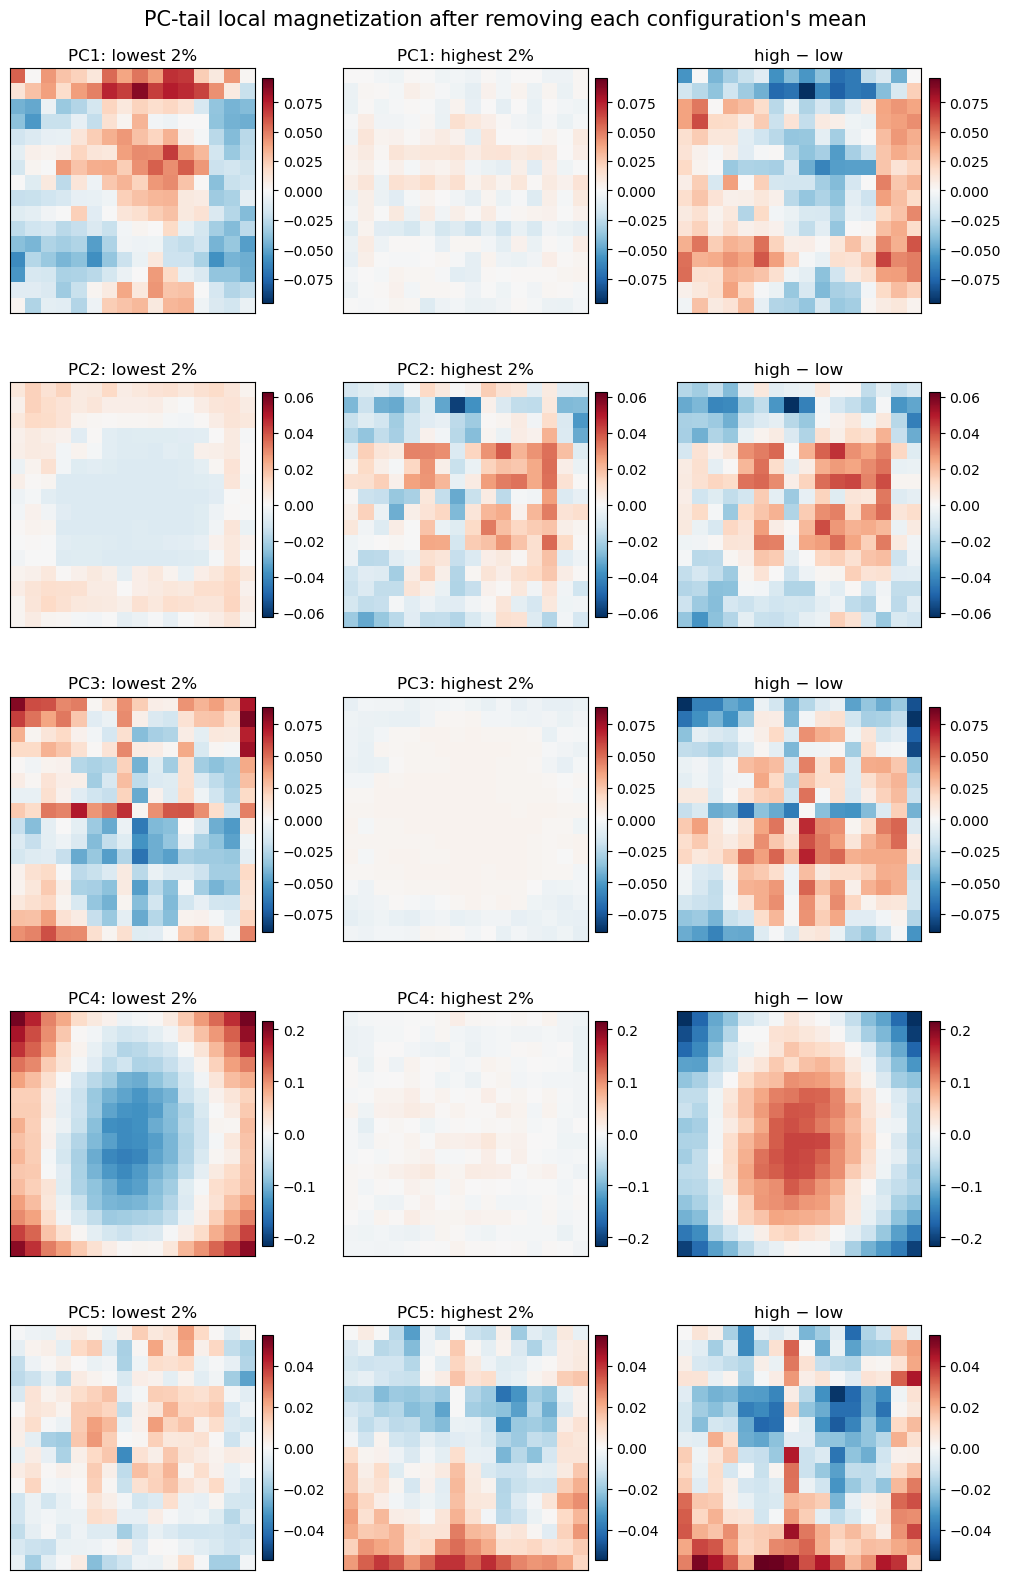

,principal_component,residual_rms,edge_minus_interior,residual_range
0,1,0.031123,0.002436,0.160000
1,2,0.019057,-0.012484,0.107742
2,3,0.030905,-0.035479,0.158065
3,4,0.084461,-0.116443,0.362903
4,5,0.022284,0.018493,0.108387


In [9]:
residual_rows = []
fig, axes = plt.subplots(5, 3, figsize=(10, 16), constrained_layout=True)

for pc_index in range(5):
    scores = np.asarray(pca90_scores[:, pc_index])
    order = np.argsort(scores)
    low_indices = order[:tail_count]
    high_indices = order[-tail_count:]

    def mean_residual(indices):
        selected = np.asarray(all_spins[indices], dtype=np.float32)
        selected -= selected.mean(axis=(1, 2), keepdims=True)
        return selected.mean(axis=0)

    low_residual = mean_residual(low_indices)
    high_residual = mean_residual(high_indices)
    residual_contrast = high_residual - low_residual
    row_limit = max(
        0.02,
        float(np.max(np.abs([low_residual, high_residual, residual_contrast]))),
    )

    for column, (image_data, title) in enumerate((
        (low_residual, f"PC{pc_index + 1}: lowest 2%"),
        (high_residual, f"PC{pc_index + 1}: highest 2%"),
        (residual_contrast, "high − low"),
    )):
        image = axes[pc_index, column].imshow(
            image_data,
            cmap="RdBu_r",
            vmin=-row_limit,
            vmax=row_limit,
            interpolation="nearest",
        )
        axes[pc_index, column].set_title(title)
        axes[pc_index, column].set_xticks([])
        axes[pc_index, column].set_yticks([])
        fig.colorbar(image, ax=axes[pc_index, column], fraction=0.046, pad=0.03)

    edge_mask = np.zeros((L, L), dtype=bool)
    edge_mask[[0, -1], :] = True
    edge_mask[:, [0, -1]] = True
    residual_rows.append({
        "principal_component": pc_index + 1,
        "residual_rms": float(np.sqrt(np.mean(residual_contrast ** 2))),
        "edge_minus_interior": float(
            residual_contrast[edge_mask].mean()
            - residual_contrast[~edge_mask].mean()
        ),
        "residual_range": float(np.ptp(residual_contrast)),
    })

fig.suptitle("PC-tail local magnetization after removing each configuration's mean", fontsize=15)
fig.savefig(
    OUTPUT_ROOT / "ising16_resnet18_raw_pc1-5_mean_subtracted_spatial_maps.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

residual_summary = pd.DataFrame(residual_rows)
residual_summary.to_csv(
    OUTPUT_ROOT / "ising16_resnet18_raw_pc1-5_mean_subtracted_spatial_summary.csv",
    index=False,
)
residual_summary

## Physical probes beyond uniform magnetization

The following observables test common alternatives without fitting a supervised model:

- **Energy/site** measures nearest-neighbor domain walls.
- **Low-\(k\) x/y amplitude** measures long-wavelength spatial modulation along each lattice direction.
- **Half imbalance** detects magnetization concentrated preferentially in opposite halves, independent of global spin inversion.
- **Checkerboard amplitude** tests the antiferromagnetic \((\pi,\pi)\) mode.

The heatmap reports the standardized shift from the lowest to highest PC-score tail. It is a descriptive tail contrast, not a correlation coefficient. A large low-\(k\) or half-imbalance shift would be evidence for a location-dependent magnetic feature.

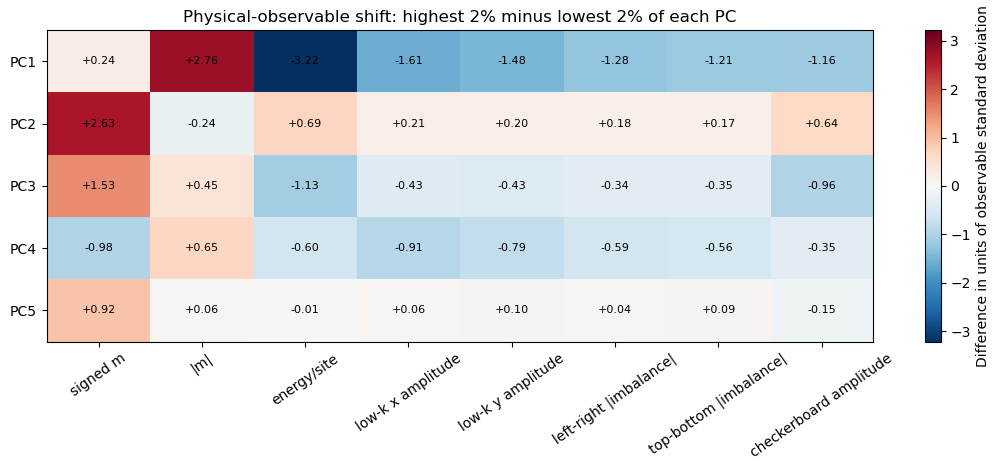

,signed m,|m|,energy/site,low-k x amplitude,low-k y amplitude,left-right |imbalance|,top-bottom |imbalance|,checkerboard amplitude
PC1,0.235731,2.759815,-3.218823,-1.609196,-1.477741,-1.275407,-1.206002,-1.158136
PC2,2.631554,-0.243287,0.685719,0.212928,0.204286,0.176772,0.166708,0.642253
PC3,1.532148,0.448838,-1.129830,-0.426511,-0.433943,-0.343512,-0.353922,-0.957085
PC4,-0.976862,0.654560,-0.602670,-0.911674,-0.786344,-0.591566,-0.561658,-0.353540
PC5,0.915556,0.058756,-0.009259,0.056694,0.096453,0.038902,0.088111,-0.147172


In [10]:
probe_names = [
    "signed m",
    "|m|",
    "energy/site",
    "low-k x amplitude",
    "low-k y amplitude",
    "left-right |imbalance|",
    "top-bottom |imbalance|",
    "checkerboard amplitude",
]
probe_values = np.empty((N_CONFIGURATIONS, len(probe_names)), dtype=np.float32)

checkerboard = (-1.0) ** (np.indices((L, L)).sum(axis=0))
x_phase = np.exp(-2j * np.pi * np.arange(L) / L)[None, :]
y_phase = np.exp(-2j * np.pi * np.arange(L) / L)[:, None]

batch_size = 10_000
for start in range(0, N_CONFIGURATIONS, batch_size):
    stop = min(start + batch_size, N_CONFIGURATIONS)
    batch = np.asarray(all_spins[start:stop], dtype=np.float32)
    m = batch.mean(axis=(1, 2))
    horizontal_bonds = batch * np.roll(batch, -1, axis=2)
    vertical_bonds = batch * np.roll(batch, -1, axis=1)
    energy = -0.5 * (horizontal_bonds + vertical_bonds).mean(axis=(1, 2))

    low_k_x = np.abs((batch * x_phase).mean(axis=(1, 2)))
    low_k_y = np.abs((batch * y_phase).mean(axis=(1, 2)))
    left_right = np.abs(
        batch[:, :, :L // 2].mean(axis=(1, 2))
        - batch[:, :, L // 2:].mean(axis=(1, 2))
    )
    top_bottom = np.abs(
        batch[:, :L // 2, :].mean(axis=(1, 2))
        - batch[:, L // 2:, :].mean(axis=(1, 2))
    )
    checker = np.abs((batch * checkerboard).mean(axis=(1, 2)))

    probe_values[start:stop] = np.column_stack([
        m, np.abs(m), energy, low_k_x, low_k_y,
        left_right, top_bottom, checker,
    ])

probe_scale = probe_values.std(axis=0, ddof=1)
tail_effects = np.empty((5, len(probe_names)), dtype=np.float64)
for pc_index in range(5):
    order = np.argsort(np.asarray(pca90_scores[:, pc_index]))
    low_indices = order[:tail_count]
    high_indices = order[-tail_count:]
    tail_effects[pc_index] = (
        probe_values[high_indices].mean(axis=0)
        - probe_values[low_indices].mean(axis=0)
    ) / probe_scale

fig, ax = plt.subplots(figsize=(11, 4.8))
limit = max(1.0, float(np.nanmax(np.abs(tail_effects))))
image = ax.imshow(tail_effects, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
ax.set(
    xticks=np.arange(len(probe_names)),
    xticklabels=probe_names,
    yticks=np.arange(5),
    yticklabels=[f"PC{i}" for i in range(1, 6)],
    title="Physical-observable shift: highest 2% minus lowest 2% of each PC",
)
ax.tick_params(axis="x", rotation=35)
for row in range(5):
    for column in range(len(probe_names)):
        ax.text(column, row, f"{tail_effects[row, column]:+.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Difference in units of observable standard deviation")
fig.tight_layout()
fig.savefig(
    OUTPUT_ROOT / "ising16_resnet18_raw_pc1-5_physical_probe_tail_shifts.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

probe_effect_table = pd.DataFrame(
    tail_effects,
    index=[f"PC{i}" for i in range(1, 6)],
    columns=probe_names,
)
probe_effect_table.to_csv(
    OUTPUT_ROOT / "ising16_resnet18_raw_pc1-5_physical_probe_tail_shifts.csv"
)
probe_effect_table

## Interpretation

- **PC1 is primarily order magnitude and domain morphology:** its tails differ strongly in $|m|$, energy, and long-wavelength spatial power.
- **PC2 is the cleanest signed-magnetization direction.**
- **PC3 mixes signed magnetization with energy/domain structure.** It does not show a stable left–right or top–bottom mode.
- **PC4 has the clearest location-dependent signature.** After removing each configuration's mean magnetization, its tail contrast has the largest residual RMS (0.084) and a strong edge-versus-interior difference (-0.116). Because the simulated lattice is periodic and translation invariant, this is more plausibly a border/resizing sensitivity of the ImageNet ResNet preprocessing than a physical Ising order parameter.
- **PC5 is mostly another signed-magnetization split** with little energy or spatial-mode change.

Thus the analysis finds a border-sensitive feature in PC4, but no convincing physical "local magnetization" order parameter. These PCs describe the frozen ResNet representation, not an orthogonal decomposition of the raw spin field, so several components can reuse magnetization information.